# Autoformer for Solar PV Forecasting

This notebook implements a complete pipeline for solar power forecasting using the Autoformer architecture.

**Configuration:**
- Lookback: 14 days (336 hours)
- Forecast: 4 days (96 hours)
- Model: Autoformer with probabilistic forecasting

## Step 1: Install Dependencies

In [ ]:
!pip install transformers datasets accelerate pandas scikit-learn matplotlib

## Step 2: Import Libraries

In [ ]:
import transformers
import sklearn
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoformerConfig, AutoformerForPrediction
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import os
from google.colab import drive

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA version: {torch.version.cuda}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Transformers version: {transformers.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")

!pip show torch

# Mount Google Drive
drive.mount('/content/drive')
DIR_OUT = '/content/drive/MyDrive/models/autoformer/5Y_with_pressure_300Epochs'
os.makedirs(DIR_OUT, exist_ok=True)

PyTorch version: 2.9.0+cu126
CUDA version: 12.6
NumPy version: 2.0.2
Pandas version: 2.2.2
Transformers version: 4.57.3
Scikit-learn version: 1.6.1
Name: torch
Version: 2.9.0+cu126
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org
Author: 
Author-email: PyTorch Team <packages@pytorch.org>
License: BSD-3-Clause
Location: /usr/local/lib/python3.12/dist-packages
Requires: filelock, fsspec, jinja2, networkx, nvidia-cublas-cu12, nvidia-cuda-cupti-cu12, nvidia-cuda-nvrtc-cu12, nvidia-cuda-runtime-cu12, nvidia-cudnn-cu12, nvidia-cufft-cu12, nvidia-cufile-cu12, nvidia-curand-cu12, nvidia-cusolver-cu12, nvidia-cusparse-cu12, nvidia-cusparselt-cu12, nvidia-nccl-cu12, nvidia-nvjitlink-cu12, nvidia-nvshmem-cu12, nvidia-nvtx-cu12, setuptools, sympy, triton, typing-extensions
Required-by: accelerate, fastai, peft, sentence-transformers, timm, torchaudio, torchdata, torchvision
Drive already mounted at /content/drive; to attempt to forc

## Step 3: Load and Prepare Data

### Load CSV

In [ ]:
dataframe = pd.read_csv('/content/drive/MyDrive/models/inputs/weather_data_with_labels_5_years_with_pressure.csv')

# Parse datetime
dataframe['date_time'] = pd.to_datetime(dataframe['date_time'], utc=True)
dataframe = dataframe.sort_values('date_time').reset_index(drop=True)

### Create Time Features

In [ ]:
dataframe['hour'] = dataframe['date_time'].dt.hour / 23.0
dataframe['day_of_year'] = dataframe['date_time'].dt.dayofyear / 365.0
dataframe['month'] = dataframe['date_time'].dt.month / 12.0
weather_columns = ['temperature', 'humidity', 'solar_radiation', 'pressure']

In [ ]:
# Configuration for model
LOOKBACK_HOURS = 336  # 14 days
FORECAST_HOURS = 96   # 4 days
NUM_TIME_FEATURES = 3 + len(weather_columns)  # hour, day_of_year, month, weather features
MODEL_DIMENSION = 128
NUM_ENCODER_LAYERS = 4
NUM_DECODER_LAYERS = 2
NUM_ATTENTION_HEADS = 8
FEEDFORWARD_DIMENSION = 512
AUTOCORRELATION_FACTOR = 3
MOVING_AVERAGE_WINDOW = 25
DROPOUT_RATE = 0.1
LAGS_SEQUENCE = [0]

### Normalize Features

In [ ]:
weather_scaler = StandardScaler()
power_scaler = MinMaxScaler()

dataframe[weather_columns] = weather_scaler.fit_transform(dataframe[weather_columns])
dataframe[['pv_output']] = power_scaler.fit_transform(dataframe[['pv_output']])

### Split Data Chronologically

In [ ]:
num_samples = len(dataframe)
train_dataframe = dataframe.iloc[:int(0.7 * num_samples)]
validation_dataframe = dataframe.iloc[int(0.7 * num_samples):int(0.85 * num_samples)]
test_dataframe = dataframe.iloc[int(0.85 * num_samples):]

print(f"Train: {len(train_dataframe)}, Val: {len(validation_dataframe)}, Test: {len(test_dataframe)}")

Train: 30311, Val: 6495, Test: 6496


### build climatology

In [ ]:
def build_climatology(df_train, weather_columns):
    # average weather for each (day_of_year, hour)
    clim = (
        df_train.groupby(["day_of_year", "hour"])[weather_columns]
        .mean()
        .reset_index()
    )
    # index: (doy, hour) -> vector weather
    clim_indexed = clim.set_index(["day_of_year", "hour"])
    return clim_indexed

def build_climatology_lookup(climatology_df, W):
    """
    Created for fast lookup inside training loop.
    """
    # global mean
    global_mean = climatology_df.mean().values.astype(np.float32)

    clim_table = np.zeros((367, 24, W), dtype=np.float32)
    valid_mask = np.zeros((367, 24), dtype=bool)

    # Fill from the MultiIndex
    idx = climatology_df.index
    doys = np.array([d for d, h in idx], dtype=np.int16)
    hrs  = np.array([h for d, h in idx], dtype=np.int8)
    vals = climatology_df.values.astype(np.float32)

    clim_table[doys, hrs, :] = vals
    valid_mask[doys, hrs] = True

    return clim_table, valid_mask, global_mean

# Create climatology
climatology = build_climatology(train_dataframe, weather_columns)
W = len(weather_columns)
clim_table, clim_valid, clim_global_mean = build_climatology_lookup(climatology, W)

# Save climatology files for prediction
np.save(DIR_OUT + '/clim_table.npy', clim_table)
np.save(DIR_OUT + '/clim_valid.npy', clim_valid)
np.save(DIR_OUT + '/clim_global_mean.npy', clim_global_mean)


# Functions for using climatology for training and prediction loops
def alpha_exponential(lead_hours, alpha_end=0.2, horizon_hours=96):
    # alpha(0)=1, alpha(horizon_hours)=alpha_end
    k = -np.log(alpha_end) / horizon_hours
    return np.exp(-k * lead_hours).astype(np.float32)

def make_future_weather_proxy(
    last_weather, future_doy, future_hour,
    clim_table, clim_valid, clim_global_mean,
    step_minutes=60, alpha_end=0.2, horizon_hours=96
):
    """
    last_weather: (W,)
    future_doy, future_hour: (H,) integer arrays
    clim_table: (367, 24, W)
    clim_valid: (367, 24) bool
    clim_global_mean: (W,)
    returns: (H, W)
    """
    future_doy = future_doy.astype(np.int16)
    future_hour = future_hour.astype(np.int8)

    H = len(future_doy)

    lead_hours = (np.arange(1, H + 1) * step_minutes) / 60.0
    alphas = alpha_exponential(lead_hours, alpha_end=alpha_end, horizon_hours=horizon_hours).astype(np.float32)

    clim_vecs = clim_table[future_doy, future_hour, :]  # fast gather
    valid = clim_valid[future_doy, future_hour]         # (H,)

    # replace missing entries with global mean
    if not valid.all():
        clim_vecs = clim_vecs.copy()
        clim_vecs[~valid] = clim_global_mean

    # blend
    proxy = alphas[:, None] * last_weather[None, :] + (1.0 - alphas)[:, None] * clim_vecs
    return proxy.astype(np.float32)



## Step 4: Create Dataset Class

In [ ]:
class SimpleSolarDataset(Dataset):
    def __init__(self, dataframe, weather_columns, clim_table=None, clim_valid=None, clim_global_mean=None, step_minutes=60, lookback_hours=336, forecast_hours=96, max_lag=1):
        self.dataframe = dataframe
        self.weather_columns = weather_columns
        self.climatology = climatology
        self.step_minutes = step_minutes
        self.lookback_hours = lookback_hours
        self.forecast_hours = forecast_hours
        self.max_lag = max_lag
        self.clim_table = clim_table
        self.clim_valid = clim_valid
        self.clim_global_mean = clim_global_mean
        self.step_minutes = step_minutes

    def __len__(self):
        return len(self.dataframe) - (self.lookback_hours + self.max_lag) - self.forecast_hours + 1

    def __getitem__(self, index):
        historical_end = index + self.lookback_hours + self.max_lag
        future_end = historical_end + self.forecast_hours

        # ---- WEATHER ----
        past_weather = self.dataframe[self.weather_columns].iloc[index:historical_end].values
        last_weather = past_weather[-1]
        # future time indices for each step
        future_doy = self.dataframe["day_of_year"].iloc[historical_end:future_end].values
        future_hour = self.dataframe["hour"].iloc[historical_end:future_end].values

        future_weather_proxy = make_future_weather_proxy(
            last_weather=last_weather,
            future_doy=future_doy,
            future_hour=future_hour,
            clim_table=self.clim_table,
            clim_valid=self.clim_valid,
            clim_global_mean=self.clim_global_mean,
            step_minutes=self.step_minutes,
            alpha_end=0.2,
            horizon_hours=self.forecast_hours * (self.step_minutes/60.0)
        )

        # ---- TIME FEATURES ----
        past_time_features = self.dataframe[['hour', 'day_of_year', 'month']].iloc[index:historical_end].values
        future_time_features = self.dataframe[['hour', 'day_of_year', 'month']].iloc[historical_end:future_end].values

        past_time_features = np.concatenate([past_time_features, past_weather], axis=-1)
        future_time_features = np.concatenate([future_time_features, future_weather_proxy], axis=-1)

        # ---- PV ----
        future_power_values = self.dataframe['pv_output'].iloc[historical_end:future_end].values

        # ---- past_values (no PV history used) ----
        past_values = np.zeros(historical_end - index, dtype=np.float32)
        past_observed_mask = np.zeros_like(past_values, dtype=bool)  # all missing

        return {
            "past_values": torch.FloatTensor(past_values),
            "past_time_features": torch.FloatTensor(past_time_features),
            "past_observed_mask": torch.BoolTensor(past_observed_mask),

            "future_values": torch.FloatTensor(future_power_values),
            "future_time_features": torch.FloatTensor(future_time_features),

            "static_categorical_features": torch.LongTensor([0]),
        }

### Create Datasets and DataLoaders

In [ ]:
max_lag = max(LAGS_SEQUENCE)

train_dataset = SimpleSolarDataset(train_dataframe,
                                  weather_columns,
                                  clim_table=clim_table,
                                  clim_valid=clim_valid,
                                  clim_global_mean=clim_global_mean,
                                  step_minutes=60,
                                  lookback_hours=LOOKBACK_HOURS,
                                  forecast_hours=FORECAST_HOURS,
                                  max_lag=max_lag)

validation_dataset = SimpleSolarDataset(validation_dataframe,
                                       weather_columns,
                                       clim_table=clim_table,
                                       clim_valid=clim_valid,
                                       clim_global_mean=clim_global_mean,
                                       step_minutes=60,
                                       lookback_hours=LOOKBACK_HOURS,
                                       forecast_hours=FORECAST_HOURS,
                                       max_lag=max_lag)

test_dataset = SimpleSolarDataset(test_dataframe,
                                 weather_columns,
                                 clim_table=clim_table,
                                 clim_valid=clim_valid,
                                 clim_global_mean=clim_global_mean,
                                 step_minutes=60,
                                 lookback_hours=LOOKBACK_HOURS,
                                 forecast_hours=FORECAST_HOURS,
                                 max_lag=max_lag)

# Create dataloaders
def collate_fn(batch):
    return {key: torch.stack([item[key] for item in batch]) for key in batch[0].keys()}

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn, num_workers=4, pin_memory=True, persistent_workers=True)
validation_loader = DataLoader(validation_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn, num_workers=4, pin_memory=True, persistent_workers=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)

## Step 5: Create Autoformer Model

### Model Configuration

In [ ]:
model_config = AutoformerConfig(
    prediction_length=FORECAST_HOURS,
    context_length=LOOKBACK_HOURS,

    # Features
    num_time_features=NUM_TIME_FEATURES,
    num_static_categorical_features=1,
    cardinality=[1],
    embedding_dimension=[2],

    # Architecture
    d_model=MODEL_DIMENSION,
    encoder_layers=NUM_ENCODER_LAYERS,
    decoder_layers=NUM_DECODER_LAYERS,
    encoder_attention_heads=NUM_ATTENTION_HEADS,
    decoder_attention_heads=NUM_ATTENTION_HEADS,
    encoder_ffn_dim=FEEDFORWARD_DIMENSION,
    decoder_ffn_dim=FEEDFORWARD_DIMENSION,

    # Autoformer-specific
    autocorrelation_factor=AUTOCORRELATION_FACTOR,
    moving_average=MOVING_AVERAGE_WINDOW,

    # Regularization
    dropout=DROPOUT_RATE,
    attention_dropout=DROPOUT_RATE,

    # Distribution for probabilistic forecasting
    distribution_output="student_t",

    #No lag sequence as theres no past PV data
    lags_sequence=LAGS_SEQUENCE,

    scaling=False,
)

### Create Model and Move to Device

In [ ]:
model = AutoformerForPrediction(model_config)

# Move to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print(f"Model parameters: {sum(parameter.numel() for parameter in model.parameters()):,}")
print(f"Device: {device}")

Model parameters: 1,447,221
Device: cuda


## Step 6: Training Loop

### Training Configuration

In [ ]:
LEARNING_RATE = 1e-4
NUM_EPOCHS = 300

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
best_validation_loss = float('inf')

In [ ]:
import time
t0 = time.time()
batch = next(iter(train_loader))
t1 = time.time()
print("Batch fetch time:", t1 - t0)

Batch fetch time: 0.256497859954834


### Train the Model

In [ ]:
import joblib
import torch
print(f"CUDA available: {torch.cuda.is_available()}")

# Check where model is located
print(f"Model device: {next(model.parameters()).device}")

training_start_time = time.time()
for epoch in range(NUM_EPOCHS):
    # Training
    model.train()
    total_train_loss = 0
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    for batch in train_loader:
        batch = {key: value.to(device) for key, value in batch.items()}

        outputs = model(
            past_values=batch['past_values'],
            past_time_features=batch['past_time_features'],
            past_observed_mask=batch['past_observed_mask'],
            future_values=batch['future_values'],
            future_time_features=batch['future_time_features'],
            static_categorical_features=batch['static_categorical_features'],
        )
        loss = outputs.loss
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_train_loss += loss.item()

    average_train_loss = total_train_loss / len(train_loader)

    # Validation
    model.eval()
    total_validation_loss = 0
    with torch.no_grad():
        for batch in validation_loader:
            batch = {key: value.to(device) for key, value in batch.items()}
            outputs = model(
                past_values=batch['past_values'],
                past_time_features=batch['past_time_features'],
                past_observed_mask=batch['past_observed_mask'],
                future_values=batch['future_values'],
                future_time_features=batch['future_time_features'],
                static_categorical_features=batch['static_categorical_features'],
            )
            total_validation_loss += outputs.loss.item()

    average_validation_loss = total_validation_loss / len(validation_loader)

    print(f"Result - Train Loss: {average_train_loss:.6f}, Val Loss: {average_validation_loss:.6f}")

    # Save best model
    if average_validation_loss < best_validation_loss:
        best_validation_loss = average_validation_loss
        torch.save(model.state_dict(), DIR_OUT + '/autoformer.pth')
        torch.save(model.state_dict(), 'best_autoformer.pth')
        joblib.dump(weather_scaler, DIR_OUT + '/autoformer_weather_scaler.pkl')
        joblib.dump(power_scaler, DIR_OUT + '/autoformer_power_scaler.pkl')
        print(f"  -> Saved best model and scalers!")
training_stop_time = time.time()
print(f"Training time: {training_stop_time - training_start_time:.2f} seconds")

CUDA available: True
Model device: cuda:0
Epoch 1/300
Result - Train Loss: -0.226151, Val Loss: -0.583608
  -> Saved best model and scalers!
Epoch 2/300
Result - Train Loss: -0.715513, Val Loss: -0.752614
  -> Saved best model and scalers!
Epoch 3/300
Result - Train Loss: -0.856335, Val Loss: -0.489439
Epoch 4/300
Result - Train Loss: -0.965691, Val Loss: -0.366772
Epoch 5/300
Result - Train Loss: -1.042691, Val Loss: -1.317025
  -> Saved best model and scalers!
Epoch 6/300
Result - Train Loss: -1.130157, Val Loss: -1.249510
Epoch 7/300
Result - Train Loss: -1.242276, Val Loss: -1.189634
Epoch 8/300
Result - Train Loss: -1.220786, Val Loss: 0.286137
Epoch 9/300
Result - Train Loss: -1.254032, Val Loss: -0.670443
Epoch 10/300
Result - Train Loss: -1.307595, Val Loss: -1.468226
  -> Saved best model and scalers!
Epoch 11/300
Result - Train Loss: -1.364447, Val Loss: -1.321908
Epoch 12/300
Result - Train Loss: -1.441638, Val Loss: -1.641770
  -> Saved best model and scalers!
Epoch 13/300


## Step 7: Evaluation and Prediction

### Load Best Model

In [ ]:
model.load_state_dict(torch.load('best_autoformer.pth'))
model.eval()

AutoformerForPrediction(
  (model): AutoformerModel(
    (scaler): AutoformerNOPScaler()
    (embedder): AutoformerFeatureEmbedder(
      (embedders): ModuleList(
        (0): Embedding(1, 2)
      )
    )
    (encoder): AutoformerEncoder(
      (value_embedding): AutoformerValueEmbedding(
        (value_projection): Linear(in_features=12, out_features=128, bias=False)
      )
      (embed_positions): AutoformerSinusoidalPositionalEmbedding(432, 128)
      (layers): ModuleList(
        (0-3): 4 x AutoformerEncoderLayer(
          (self_attn): AutoformerAttention(
            (k_proj): Linear(in_features=128, out_features=128, bias=True)
            (v_proj): Linear(in_features=128, out_features=128, bias=True)
            (q_proj): Linear(in_features=128, out_features=128, bias=True)
            (out_proj): Linear(in_features=128, out_features=128, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (activation_fn): G

In [ ]:
# Check generate signature
import inspect
print(inspect.signature(model.generate))

(past_values: torch.Tensor, past_time_features: torch.Tensor, future_time_features: torch.Tensor, past_observed_mask: Optional[torch.Tensor] = None, static_categorical_features: Optional[torch.Tensor] = None, static_real_features: Optional[torch.Tensor] = None, output_attentions: Optional[bool] = None, output_hidden_states: Optional[bool] = None) -> transformers.modeling_outputs.SampleTSPredictionOutput


### Generate Predictions on Test Set

In [ ]:
predictions_normalized = []
actuals_normalized = []
import torch
print(f"CUDA available: {torch.cuda.is_available()}")

# Check where model is located
print(f"Model device: {next(model.parameters()).device}")

testing_start_time = time.time()

i = 0

with torch.no_grad():
    for batch in test_loader:
        batch = {key: value.to(device) for key, value in batch.items()}

        # Generate predictions
        outputs = model.generate(
            past_values=batch['past_values'],
            past_time_features=batch['past_time_features'],
            past_observed_mask=batch['past_observed_mask'],
            future_time_features=batch['future_time_features'],
            static_categorical_features=batch['static_categorical_features'],
        )

        predicted_normalized = outputs.sequences.median(dim=1).values.cpu().numpy()
        actual_normalized = batch['future_values'].cpu().numpy()

        predictions_normalized.append(predicted_normalized)
        actuals_normalized.append(actual_normalized)

testing_stop_time = time.time()
print(f"Testing time: {testing_stop_time - testing_start_time:.2f} seconds")

# Concatenate
predictions_normalized = np.concatenate(predictions_normalized, axis=0)
actuals_normalized = np.concatenate(actuals_normalized, axis=0)

CUDA available: True
Model device: cuda:0


### Inverse Transform and Calculate Metrics

predictions_normalized shape: (6065, 96)
actuals_normalized shape: (6065, 96)

EVALUATING MODEL PERFORMANCE

OVERALL TEST SET PERFORMANCE

Alpha = 5.0% (±5.0% error tolerance):
  - Success Rate: 80.11%
  - Conditional MAE: 59.3404

Alpha = 10.0% (±10.0% error tolerance):
  - Success Rate: 88.24%
  - Conditional MAE: 66.7838

Alpha = 15.0% (±15.0% error tolerance):
  - Success Rate: 91.50%
  - Conditional MAE: 68.2403

Alpha = 20.0% (±20.0% error tolerance):
  - Success Rate: 98.62%
  - Conditional MAE: 71.2405

ADDITIONAL METRICS

Overall MAE: 16.57 W
Overall RMSE: 32.04 W
Daytime MAPE: 8.99%


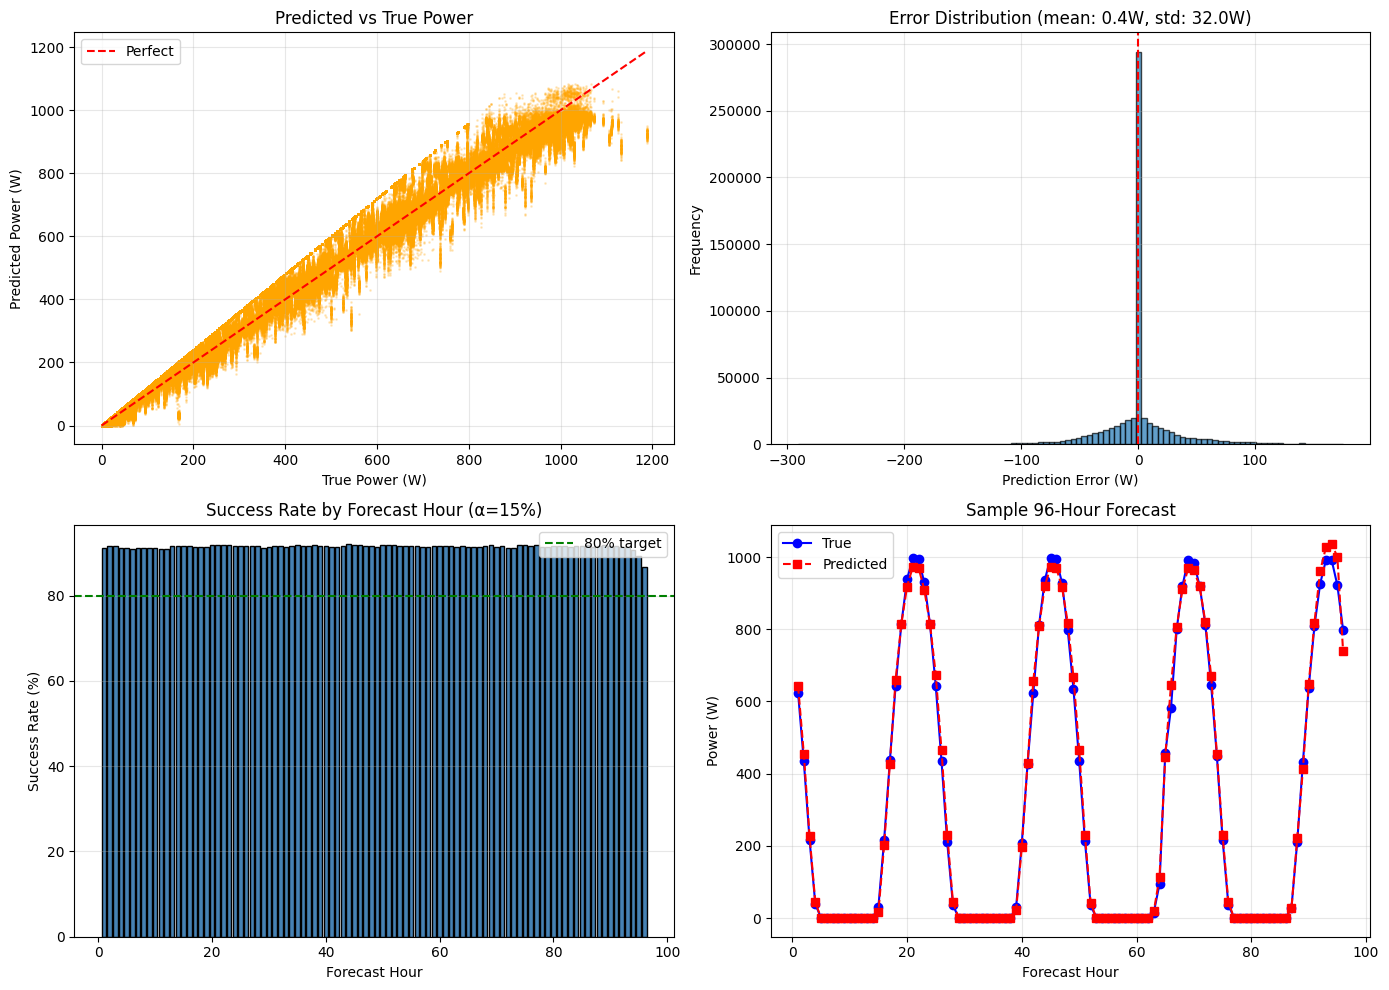


✓ Results plot saved to 'autoformer_results.png'

✓ Results saved to CSV files


In [ ]:
def evaluate_predictions(y_true, y_pred, alpha=0.1):
    """
    Evaluate predictions using success rate metric.

    Success criteria: abs(pred - true) < (pred + true) * alpha / 2
    With minimum threshold of 20W
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    threshold = (y_pred + y_true) * alpha / 2
    threshold = np.maximum(threshold, 20)  # Minimum 20W threshold

    errors = np.abs(y_pred - y_true)
    successful_mask = errors < threshold
    incorrect_mask = ~successful_mask

    success_rate = np.mean(successful_mask) * 100

    if np.any(incorrect_mask):
        conditional_mae = np.mean(errors[incorrect_mask])
    else:
        conditional_mae = 0.0

    return success_rate, conditional_mae


def evaluate_model_comprehensive(predictions_normalized, actuals_normalized, power_scaler):
    """
    Comprehensive model evaluation with all metrics.
    """
    print("\n" + "=" * 70)
    print("EVALUATING MODEL PERFORMANCE")
    print("=" * 70)

    alphas = [0.05, 0.10, 0.15, 0.2]

    # Clip predictions to [0, 1] range
    predictions_normalized = np.clip(predictions_normalized, 0, 1)

    # Convert back to original scale
    y_pred = power_scaler.inverse_transform(predictions_normalized.reshape(-1, 1)).flatten()
    y_true = power_scaler.inverse_transform(actuals_normalized.reshape(-1, 1)).flatten()

    y_pred = np.clip(y_pred, 0, y_true * 1.2)  # hard limit at the maximum possible output + 20%

    # Get forecast hours from shape
    FORECAST_HOURS = predictions_normalized.shape[1]

    # Reshape for per-hour analysis
    y_pred_reshaped = y_pred.reshape(-1, FORECAST_HOURS)
    y_true_reshaped = y_true.reshape(-1, FORECAST_HOURS)

    # Overall evaluation
    print("\n" + "=" * 70)
    print("OVERALL TEST SET PERFORMANCE")
    print("=" * 70)

    results_data = []
    for alpha in alphas:
        success_rate, conditional_mae = evaluate_predictions(y_true, y_pred, alpha)
        print(f"\nAlpha = {alpha*100:.1f}% (±{alpha*100:.1f}% error tolerance):")
        print(f"  - Success Rate: {success_rate:.2f}%")
        print(f"  - Conditional MAE: {conditional_mae:.4f}")

        # Add to results data
        results_data.append({
            'Alpha': alpha,
            'Success_Rate_%': success_rate,
            'Conditional_MAE': conditional_mae
        })

    results_df = pd.DataFrame(results_data)
    results_df = results_df.sort_values(['Alpha']).reset_index(drop=True)

    # Additional metrics
    print("\n" + "=" * 70)
    print("ADDITIONAL METRICS")
    print("=" * 70)

    # Overall metrics
    mae = np.mean(np.abs(y_pred - y_true))
    rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))

    # Daytime MAPE (avoid division by zero)
    daytime_mask = y_true > 15
    y_true_day = y_true[daytime_mask]
    y_pred_day = y_pred[daytime_mask]
    mape_day = np.mean(np.abs((y_true_day - y_pred_day) / y_true_day)) * 100

    print(f"\nOverall MAE: {mae:.2f} W")
    print(f"Overall RMSE: {rmse:.2f} W")
    print(f"Daytime MAPE: {mape_day:.2f}%")

    additional_metrics = {
        'MAE': mae,
        'RMSE': rmse,
        'Daytime_MAPE': mape_day
    }
    additional_metrics_df = pd.DataFrame(list(additional_metrics.items()),
                                      columns=['Metric', 'Value'])

    return {
        'y_true': y_true,
        'y_pred': y_pred,
        'y_true_reshaped': y_true_reshaped,
        'y_pred_reshaped': y_pred_reshaped,
        'results_df': results_df,
        'additional_metrics_df': additional_metrics_df,
        'FORECAST_HOURS': FORECAST_HOURS
    }


def plot_results(results, output_dir='.'):
    """Create visualization plots"""
    y_true = results['y_true']
    y_pred = results['y_pred']
    FORECAST_HOURS = results['FORECAST_HOURS']

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. Scatter plot
    ax1 = axes[0, 0]
    ax1.scatter(y_true, y_pred, alpha=0.2, s=1, c='orange')
    ax1.plot([0, y_true.max()], [0, y_true.max()], 'r--', label='Perfect')
    ax1.set_xlabel('True Power (W)')
    ax1.set_ylabel('Predicted Power (W)')
    ax1.set_title('Predicted vs True Power')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. Error distribution
    ax2 = axes[0, 1]
    errors = y_pred - y_true
    ax2.hist(errors, bins=100, edgecolor='black', alpha=0.7)
    ax2.axvline(x=0, color='r', linestyle='--')
    ax2.set_xlabel('Prediction Error (W)')
    ax2.set_ylabel('Frequency')
    ax2.set_title(f'Error Distribution (mean: {np.mean(errors):.1f}W, std: {np.std(errors):.1f}W)')
    ax2.grid(True, alpha=0.3)

    # 3. Per-hour success rate
    ax3 = axes[1, 0]
    y_true_reshaped = results['y_true_reshaped']
    y_pred_reshaped = results['y_pred_reshaped']

    hourly_success = []
    for h in range(FORECAST_HOURS):
        sr, _ = evaluate_predictions(y_true_reshaped[:, h], y_pred_reshaped[:, h], alpha=0.15)
        hourly_success.append(sr)

    ax3.bar(range(1, FORECAST_HOURS+1), hourly_success, color='steelblue', edgecolor='black')
    ax3.axhline(y=80, color='g', linestyle='--', label='80% target')
    ax3.set_xlabel('Forecast Hour')
    ax3.set_ylabel('Success Rate (%)')
    ax3.set_title('Success Rate by Forecast Hour (α=15%)')
    ax3.legend()
    ax3.grid(True, alpha=0.3, axis='y')

    # 4. Sample prediction
    ax4 = axes[1, 1]
    sample_idx = len(y_true_reshaped) // 2  # Middle sample
    ax4.plot(range(1, FORECAST_HOURS+1), y_true_reshaped[sample_idx], 'b-o', label='True')
    ax4.plot(range(1, FORECAST_HOURS+1), y_pred_reshaped[sample_idx], 'r--s', label='Predicted')
    ax4.set_xlabel('Forecast Hour')
    ax4.set_ylabel('Power (W)')
    ax4.set_title('Sample 96-Hour Forecast')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(output_dir + '/autoformer_results.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\n✓ Results plot saved to 'autoformer_results.png'")

print(f"predictions_normalized shape: {predictions_normalized.shape}")
print(f"actuals_normalized shape: {actuals_normalized.shape}")

# Evaluate model comprehensively
results = evaluate_model_comprehensive(predictions_normalized, actuals_normalized, power_scaler)

# Plot results
plot_results(results, output_dir=DIR_OUT)

# Save results to CSV
results['results_df'].to_csv(DIR_OUT + '/autoformer_evaluation_results.csv', index=False)
results['additional_metrics_df'].to_csv(DIR_OUT + '/autoformer_additional_metrics.csv', index=False)
print("\n✓ Results saved to CSV files")